In [1]:
import numpy as np
import importlib
import Sim_Parameters
#from config import *
from simulation import run
from visualize import plot_initial, plot_trajectory, plot_force
import numpy as np
from integrator import step
from driving import update_traps
from forces import trap_force
from hydrodynamics import mobility_matrix
from simulation import run
import matplotlib.pyplot as plt

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


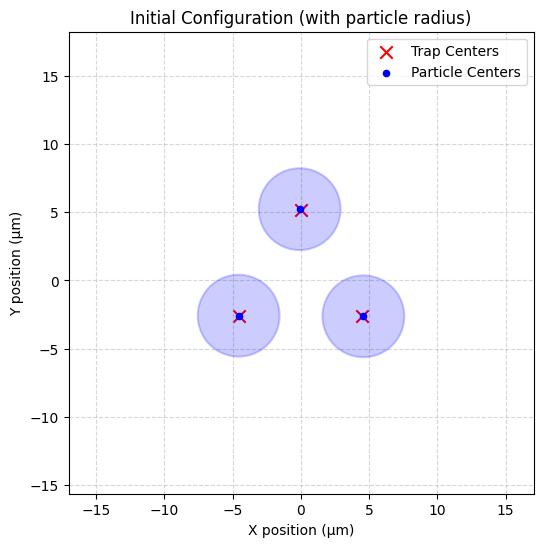

[[ 4.58599192e-06 -2.62322583e-06]
 [-8.30205106e-08  5.22542005e-06]
 [-4.55231624e-06 -2.57774083e-06]]


In [2]:
importlib.reload(Sim_Parameters)
from Sim_Parameters import *
# Initial visualization
plot_initial(pos0, trap0, a)
print(pos0)

In [3]:
H = mobility_matrix(pos0, eta)
print("Mobility Matrix H:")
print(H)
D = kBT * (H + H.T) / 2  # Ensure symmetry
A = np.linalg.cholesky(D )
print("Cholesky factor A:")
with np.printoptions(precision=2, suppress=False, formatter={'float': '{:.2e}'.format}):
    print(A)

Mobility Matrix H:
[[20000000.                0.          6215476.94279813 -2165090.3446396
   9848406.16011744   -24509.41359544]
 [       0.         20000000.         -2165090.3446396   8567038.79652089
    -24509.41359544  4924386.06970786]
 [ 6215476.94279813 -2165090.3446396  20000000.                0.
   6240319.04847986  2158191.35668061]
 [-2165090.3446396   8567038.79652089        0.         20000000.
   2158191.35668061  8772296.4818377 ]
 [ 9848406.16011744   -24509.41359544  6240319.04847986  2158191.35668061
  20000000.                0.        ]
 [  -24509.41359544  4924386.06970786  2158191.35668061  8772296.4818377
         0.         20000000.        ]]
Cholesky factor A:
[[2.87e-07 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 2.87e-07 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [8.91e-08 -3.10e-08 2.71e-07 0.00e+00 0.00e+00 0.00e+00]
 [-3.10e-08 1.23e-07 2.43e-08 2.56e-07 0.00e+00 0.00e+00]
 [1.41e-07 -3.51e-10 4.82e-08 4.74e-08 2.40e-07 0.00e+00]
 [-3.51e-10 7

In [4]:
print(steps)

100000


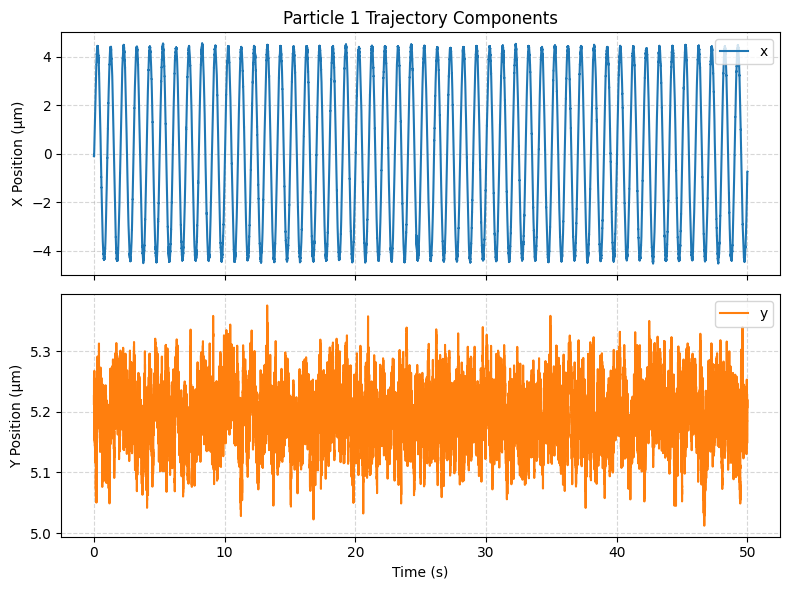

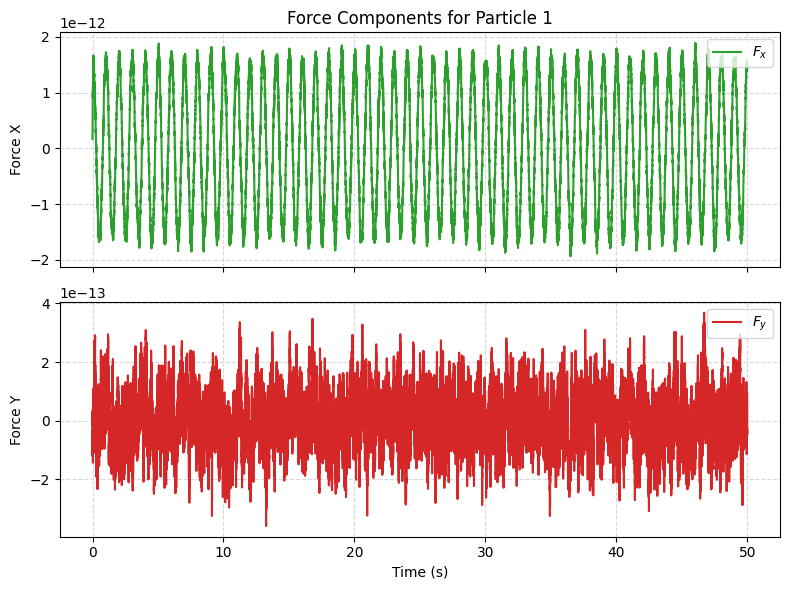

In [5]:
# Run simulation
traj, forces, traps = run(
    pos0,
    trap0,
    kappa,
    drive,
    eta,
    dt,
    steps
)

# After shear
plot_trajectory(traj, dt,particle=1)
plot_force(forces, dt,particle=1)

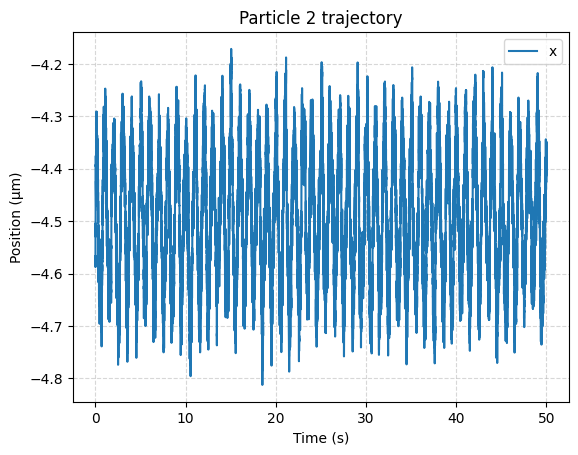

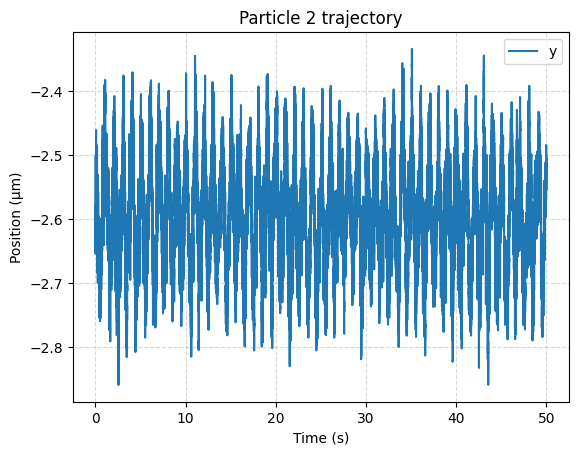

In [6]:
num_steps = len(traj)

    # Create an array of timestamps: [0, dt, 2*dt, ..., (num_steps-1)*dt]
time_axis = np.arange(num_steps) * dt
particle = 2
plt.figure()

    # Plot x  coordinates against the physical time axis
plt.plot(time_axis, traj[:, particle, 0]*1e6, label="x")
    

plt.xlabel("Time (s)")  # Added axis label
plt.ylabel("Position (μm)")
plt.legend()
plt.title(f"Particle {particle} trajectory")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure()

# Plot y coordinates against the physical time axis

plt.plot(time_axis, traj[:, particle, 1]*1e6, label="y")

plt.xlabel("Time (s)")  # Added axis label
plt.ylabel("Position (μm)")
plt.legend()
plt.title(f"Particle {particle} trajectory")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

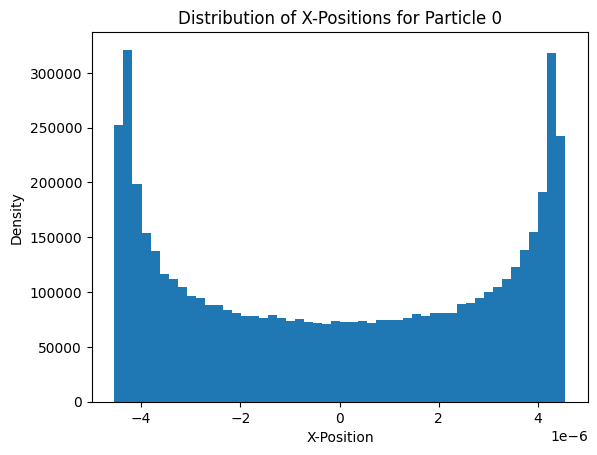

In [7]:
plt.figure()
# Plot histogram of x-positions of particle 0
plt.hist(traj[:, 1, 0], bins=50, density=True)
plt.xlabel("X-Position")
plt.ylabel("Density")
plt.title("Distribution of X-Positions for Particle 0")
plt.show()

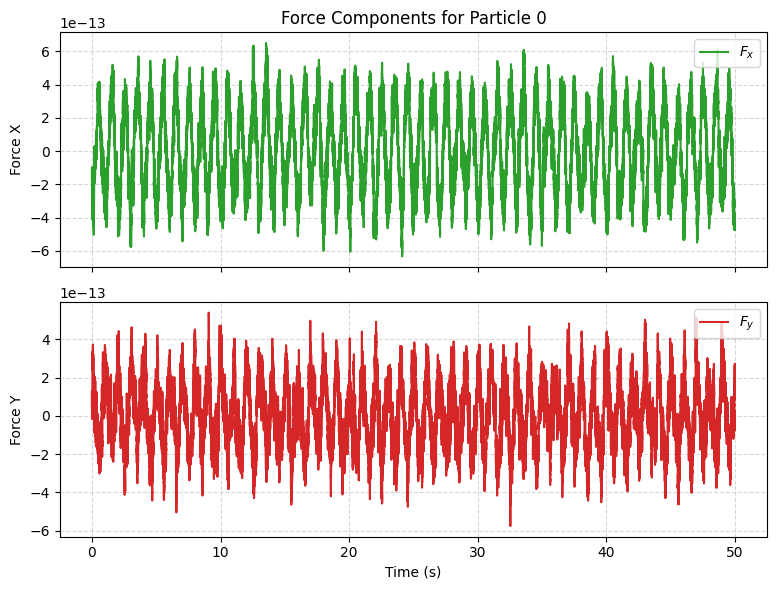

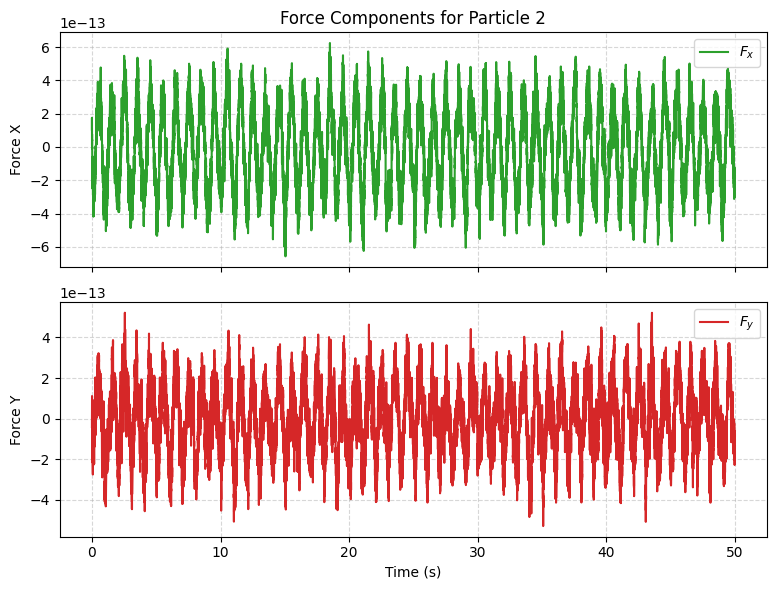

In [8]:
plot_force(forces, dt,particle=0)
plot_force(forces, dt,particle=2)

In [11]:
x = traj[:, 2,0]
print(6 * np.pi * eta * a)
kBT = 1.38e-23 * (273 + 25)
k_eff = kBT / np.var(x)
print(f"Effective stiffness from trajectory: {k_eff:.2e} N/m")

5e-08
Effective stiffness from trajectory: 2.71e-07 N/m


In [10]:
fluctuations = (traj - trap0)*1e6

fluctuations = fluctuations.reshape(fluctuations.shape[0], -1)
C = np.cov(fluctuations.T)
print("Covariance Matrix:\n")
print(C)
diagonal = np.diag(np.diag(C))
offdiag_norm = np.linalg.norm(C - diagonal)
diagonal_norm = np.linalg.norm(diagonal)
print("\nOff-diagonal norm / Diagonal norm =", offdiag_norm/diagonal_norm)

Covariance Matrix:

[[ 1.60103621e-02 -8.15036119e-03  5.48897017e-02  9.96678544e-05
   1.33754600e-02  7.93312520e-03]
 [-8.15036119e-03  7.16609629e-03 -5.43725687e-02 -7.44802577e-05
  -7.92035291e-03 -4.78523093e-03]
 [ 5.48897017e-02 -5.43725687e-02  9.72299301e+00  7.02657306e-03
   3.53070066e-02  4.33394071e-02]
 [ 9.96678544e-05 -7.44802577e-05  7.02657306e-03  2.18418811e-03
   3.83827036e-05 -1.57938511e-06]
 [ 1.33754600e-02 -7.92035291e-03  3.53070066e-02  3.83827036e-05
   1.51999457e-02  7.80490037e-03]
 [ 7.93312520e-03 -4.78523093e-03  4.33394071e-02 -1.57938511e-06
   7.80490037e-03  6.97078075e-03]]

Off-diagonal norm / Diagonal norm = 0.01424990222876267
